# Dados Desbalanceados - US Accidents Dataset

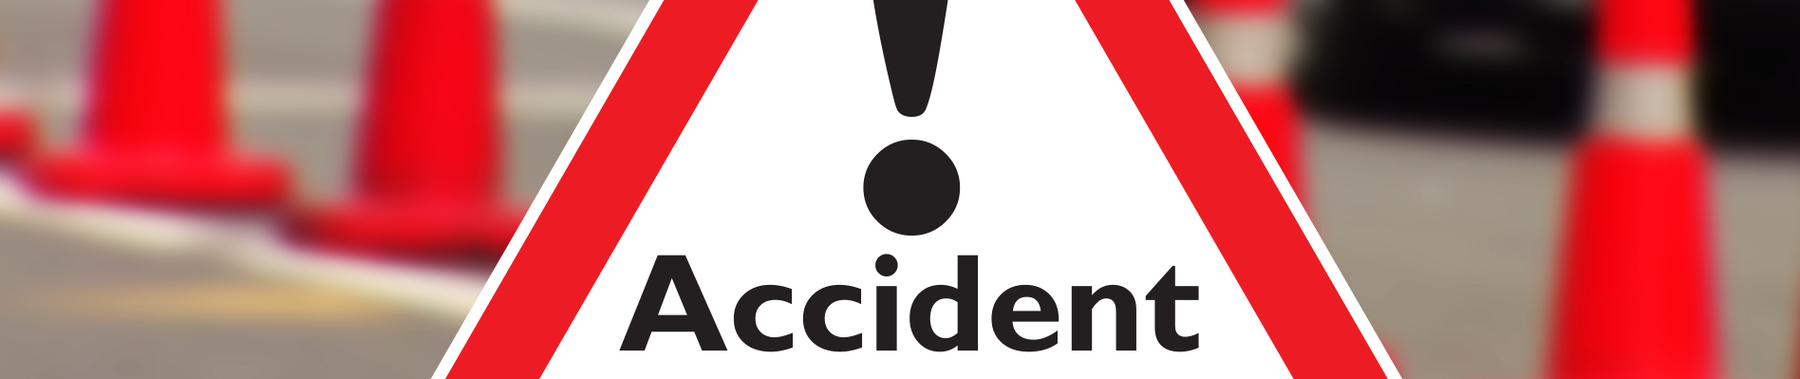

## Preparação

In [7]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [8]:
df = pd.read_csv("C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/US_Accidents/US_Accidents.csv")

In [9]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2716600,3,08-02-2016 00:37,08-02-2016 06:37,40.10891,-83.09286,40.11206,-83.03187,3.230,Between Sawmill Rd/Exit 20 and OH-315/Olentang...,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2716601,2,08-02-2016 05:56,08-02-2016 11:56,39.86542,-84.06280,39.86501,-84.04873,0.747,At OH-4/OH-235/Exit 41 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-2716602,2,08-02-2016 06:15,08-02-2016 12:15,39.10266,-84.52468,39.10209,-84.52396,0.055,At I-71/US-50/Exit 1 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Day
3,A-2716603,2,08-02-2016 06:15,08-02-2016 12:15,39.10148,-84.52341,39.09841,-84.52241,0.219,At I-71/US-50/Exit 1 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Day
4,A-2716604,2,08-02-2016 06:51,08-02-2016 12:51,41.06213,-81.53784,41.06217,-81.53547,0.123,At Dart Ave/Exit 21 - Accident.,...,False,False,False,False,False,False,Night,Night,Day,Day


In [10]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="%d-%m-%Y %H:%M", errors="coerce")

In [11]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2716600,3,2016-02-08 00:37:00,08-02-2016 06:37,40.10891,-83.09286,40.11206,-83.03187,3.230,Between Sawmill Rd/Exit 20 and OH-315/Olentang...,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2716601,2,2016-02-08 05:56:00,08-02-2016 11:56,39.86542,-84.06280,39.86501,-84.04873,0.747,At OH-4/OH-235/Exit 41 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-2716602,2,2016-02-08 06:15:00,08-02-2016 12:15,39.10266,-84.52468,39.10209,-84.52396,0.055,At I-71/US-50/Exit 1 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Day
3,A-2716603,2,2016-02-08 06:15:00,08-02-2016 12:15,39.10148,-84.52341,39.09841,-84.52241,0.219,At I-71/US-50/Exit 1 - Accident.,...,False,False,False,False,False,False,Night,Night,Night,Day
4,A-2716604,2,2016-02-08 06:51:00,08-02-2016 12:51,41.06213,-81.53784,41.06217,-81.53547,0.123,At Dart Ave/Exit 21 - Accident.,...,False,False,False,False,False,False,Night,Night,Day,Day


In [12]:
df = df[df["Start_Time"].dt.year.isin([2017])]

In [13]:
# Transformando o target em uma classificação binária (indicando se foi grave ou não)
df["High_Severity"] = df["Severity"].apply(lambda x: 1 if x >= 3 else 0)

In [14]:
df["High_Severity"].value_counts(normalize=True)

High_Severity
0    0.692745
1    0.307255
Name: proportion, dtype: float64

In [15]:
features = [
  'Start_Lat',
  'Start_Lng',
  'End_Lat',
  'End_Lng',
  'Distance(mi)',
  'Temperature(F)',
  'Wind_Chill(F)',
  'Humidity(%)',
  'Pressure(in)',
  'Visibility(mi)',
  'Wind_Speed(mph)',
  'Precipitation(in)'
]

target = "High_Severity"

In [16]:
X = df[features]
y = df[target]

In [17]:
X = X.fillna(0)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test,  y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22530
           1       0.71      0.51      0.60      9873

    accuracy                           0.79     32403
   macro avg       0.76      0.71      0.73     32403
weighted avg       0.78      0.79      0.78     32403



## Random Oversampleing

In [20]:
### pip install --upgrade pip

In [21]:
### pip install imblearn

In [22]:
from imblearn.over_sampling import RandomOverSampler

In [23]:
oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

In [24]:
y_train_over.value_counts(normalize=True)

High_Severity
1    0.5
0    0.5
Name: proportion, dtype: float64

In [25]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_over, y_train_over)

y_pred = model.predict(X_test)
print(classification_report(y_test,  y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85     22530
           1       0.66      0.58      0.62      9873

    accuracy                           0.78     32403
   macro avg       0.74      0.73      0.73     32403
weighted avg       0.78      0.78      0.78     32403



## Random Undersampling

In [26]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

In [27]:
y_train_under.value_counts(normalize=True)

High_Severity
0    0.5
1    0.5
Name: proportion, dtype: float64

In [28]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_under, y_train_under)

y_pred = model.predict(X_test)
print(classification_report(y_test,  y_pred))

              precision    recall  f1-score   support

           0       0.86      0.71      0.78     22530
           1       0.53      0.75      0.62      9873

    accuracy                           0.72     32403
   macro avg       0.70      0.73      0.70     32403
weighted avg       0.76      0.72      0.73     32403



In [29]:
y_train.shape

(75605,)

In [30]:
y_train_over.shape

(104584,)

In [31]:
y_train_under.shape

(46626,)

## SMOTE

In [32]:
from imblearn.over_sampling import SMOTE

In [33]:
smote_sampler = SMOTE(random_state=42)
X_train_smote,  y_train_smote = smote_sampler.fit_resample(X_train, y_train)

In [35]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83     22530
           1       0.60      0.65      0.63      9873

    accuracy                           0.76     32403
   macro avg       0.72      0.73      0.73     32403
weighted avg       0.77      0.76      0.76     32403

